## Project:

# **Online Course Engagement Prediction**

as we all known nowdays by their busy all are showing intrest on Online Courses to improve their knowledge

so for these we decided to do project on these




### Table Of Contents <a class="anchor" id="menu"></a>

* [Project Steps](#main)
    * [0. Data Collection](#dc)
    * [1. Data Validation & Basic Cleaning](#dv)
    
        @ Insights
    
    * [2. Data Understanding (EDA)](#eda)
    * [3. Missing Values & Outliers Handling](#naout)
    
        @ Predictive Modeling
    * [4. Predictive Modeling (Machine Learning)](#pm)
        * [4.1 X & y](#xy)
        * [4.2 Feature Engineering](#fe)
        * [4.3 Train-Test Split](#tt)
        * [4.4 Modeling](#model)
        * [4.5 Evaluation](#eval)
        * [4.6 Hypparam Tuning (if required)](#hyp)
        * [4.7 Model Deployment](#dep)
        * [4.8 Real Time Prediction](#pred)

Importing requried Libraries

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
!pip install simple_colors
import simple_colors
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np
import sklearn.preprocessing
from sklearn.preprocessing import LabelEncoder

Reading the File

In [ ]:
df = pd.read_csv('/content/online_course_engagement_data.csv')

***Data validation***

In [ ]:
df

,UserID,CourseCategory,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion
0,5618,Health,29.979719,17,3,50.365656,20.860773,1,0
1,4326,Arts,27.802640,1,5,62.615970,65.632415,1,0
2,5849,Arts,86.820485,14,2,78.458962,63.812007,1,1
3,4992,Science,35.038427,17,10,59.198853,95.433162,0,1
4,3866,Programming,92.490647,16,0,98.428285,18.102478,0,0
...,...,...,...,...,...,...,...,...,...
8995,8757,Health,37.445225,14,4,54.469359,32.990704,1,0
8996,894,Science,48.631443,7,7,59.413257,0.254625,0,0
8997,6323,Health,38.212512,3,3,69.508297,70.188159,1,0
8998,3652,Health,70.048665,13,10,79.655182,72.975225,1,1


We are taking only 2000 Rows for faster Execution

In [ ]:
df = df.iloc[:2000:]

In [ ]:
#dataset shape
df.shape

(2000, 9)

In [ ]:
#dataset columns
df.columns

Index(['UserID', 'CourseCategory', 'TimeSpentOnCourse',
       'NumberOfVideosWatched', 'NumberOfQuizzesTaken', 'QuizScores',
       'CompletionRate', 'DeviceType', 'CourseCompletion'],
      dtype='object')

In [ ]:
#checking for the unique values in each columns
uniqueValues = df.nunique()
uniqueValues

,0
UserID,1956
CourseCategory,5
TimeSpentOnCourse,1956
NumberOfVideosWatched,21
NumberOfQuizzesTaken,11
QuizScores,1956
CompletionRate,1956
DeviceType,2
CourseCompletion,2


Converting A Column Data Into Lower Case

In [ ]:
def lowercase(df):
  for col in df.select_dtypes("O"):
    df[col] = df[col].str.lower()

In [ ]:
lowercase(df)

<ipython-input-10-08d37c8014fc>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].str.lower()


Since our data has no null values we created some null values in 2 columns

**'NumberOfVediousWatched'** column has 10% null values and **'CompletionRate'** column has 5% null values

In [ ]:
# 1. Replace ~10% of Test_Scores with null values
df.loc[df.sample(frac=0.1, random_state=42).index, 'NumberOfVideosWatched'] = np.nan
# 2. Replace ~5% of Parental_Education with null values
df.loc[df.sample(frac=0.05, random_state=42).index, 'CompletionRate'] = np.nan
df

,UserID,CourseCategory,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion
0,5618,health,29.979719,17.0,3,50.365656,20.860773,1,0
1,4326,arts,27.802640,1.0,5,62.615970,65.632415,1,0
2,5849,arts,86.820485,14.0,2,78.458962,63.812007,1,1
3,4992,science,35.038427,17.0,10,59.198853,95.433162,0,1
4,3866,programming,92.490647,16.0,0,98.428285,18.102478,0,0
...,...,...,...,...,...,...,...,...,...
1995,6685,arts,87.712686,18.0,0,61.083430,28.069630,0,0
1996,1204,programming,17.905268,13.0,9,82.522489,52.966201,0,0
1997,1195,health,79.196597,0.0,7,87.195172,24.999775,1,0
1998,666,programming,38.923868,3.0,1,50.316308,93.818504,0,0


In [ ]:
df.isnull().sum()

,0
UserID,0
CourseCategory,0
TimeSpentOnCourse,0
NumberOfVideosWatched,200
NumberOfQuizzesTaken,0
QuizScores,0
CompletionRate,100
DeviceType,0
CourseCompletion,0


Duplicates Rows Handeling

In [ ]:
df.duplicated().sum()

np.int64(38)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(1962, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1962 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   UserID                 1962 non-null   int64  
 1   CourseCategory         1962 non-null   object 
 2   TimeSpentOnCourse      1962 non-null   float64
 3   NumberOfVideosWatched  1762 non-null   float64
 4   NumberOfQuizzesTaken   1962 non-null   int64  
 5   QuizScores             1962 non-null   float64
 6   CompletionRate         1862 non-null   float64
 7   DeviceType             1962 non-null   int64  
 8   CourseCompletion       1962 non-null   int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 153.3+ KB


***Analysis***

EDA is divided into major two types of analysis


Uni-Variate|Bi-Variate|Multi-Variate
---|-----|------
Data study of single column|Data study between two columns|Data Study between three or more columns

* **Uni-Variate Analysis - Study of Individual Column data**
    - Descriptive Stats Univariate measures,
        - Numeric Column
            - Discrete
                - round(Mean), round(Median), Mode, Five Number Summary, Std, Skewness, Kurtosis
            - Continuous
                - - Mean, Median, Five Number Summary, Std, Skewness, Kurtosis
        - Categorical & Boolean Column
            - nunique
            - unique
            - FDT
            - Mode
        - Date Time Column
            - Start Date, End Date

In [ ]:
# Writing a short code for all the univariate study
from simple_colors import * # for color print

# To Supress Scientific Notation
pd.set_option('display.float_format', lambda x: '%.2f' % x) # for 2 float points

# Assign 'crops' dataframe to 'vdata' for analysis
vdata = df

for col in vdata.columns:

    if vdata[col].dtype == object or vdata[col].dtype==bool: # categorical or boolean
        print(green("Column:", ['bold']), black(col, ['bold']))
        print(blue("=============================================================", ['bold']))
        print()
        print(cyan("           Descriptive Stats        ", ['bold']))
        print(cyan("<----------------------------------->",['bold']))
        print()
        print(magenta("Number of Unique Classes:", ['bold']), vdata[col].nunique())
        print(magenta("Unique Classes:", ['bold']))
        print(vdata[col].unique())
        print()
        print(magenta("Each Class Count (FDT):", ['bold']))
        print(vdata[col].value_counts())
        print()
        print(magenta("Each Class Percentage:", ['bold']))
        print(round((vdata[col].value_counts()/len(vdata))*100, 2))
        print()
        print(magenta("Mode: (Most Repeated or Higher Count Class):", ['bold']), vdata[col].mode()[0])
        print()

    elif vdata[col].dtype == 'int32' or vdata[col].dtype == 'int64': # numeric discrete

        # Using Describe function in pandas dataframe to get all the above numeric column stats measures

        print(green("Column:", ['bold']), black(col, ['bold']))
        print(blue("=============================================================", ['bold']))
        print()
        print(cyan("           Descriptive Stats        ", ['bold']))
        print(cyan("<----------------------------------->",['bold']))
        print()
        print(round(vdata[col].describe()))
        print()
        print(f"Skewness: {round(vdata[col].skew(),2)}")
        print(f"Kurtosis: {round(vdata[col].kurt(),2)}")
        print()

    elif vdata[col].dtype == 'float32' or vdata[col].dtype == 'float64': # numeric continuous

        # Using Describe function in pandas dataframe to get all the above numeric column stats measures

        print(green("Column:", ['bold']), black(col, ['bold']))
        print(blue("=============================================================", ['bold']))
        print()
        print(cyan("           Descriptive Stats        ", ['bold']))
        print(cyan("<----------------------------------->",['bold']))
        print()
        print(round(vdata[col].describe()))
        print()
        print(f"Skewness: {round(vdata[col].skew(),2)}")
        print(f"Kurtosis: {round(vdata[col].kurt(),2)}")
        print()

    elif vdata[col].dtype == 'datetime64[ns]':

        print(green("Column:", ['bold']), black(col, ['bold']))
        print(blue("=============================================================", ['bold']))
        print()
        print(cyan("           Descriptive Stats        ", ['bold']))
        print(cyan("<----------------------------------->",['bold']))
        print()
        print(f"Start Date: {vdata[col].min()}")
        print(f"End Date: {vdata[col].max()}")
        print()

Column: UserID

           Descriptive Stats        
<----------------------------------->

count   1962.00
mean    4497.00
std     2616.00
min        3.00
25%     2291.00
50%     4423.00
75%     6738.00
max     9000.00
Name: UserID, dtype: float64

Skewness: 0.03
Kurtosis: -1.19

Column: CourseCategory

           Descriptive Stats        
<----------------------------------->

Number of Unique Classes: 5
Unique Classes:
['health' 'arts' 'science' 'programming' 'business']

Each Class Count (FDT):
CourseCategory
business       417
science        404
programming    392
arts           381
health         368
Name: count, dtype: int64

Each Class Percentage:
CourseCategory
business      21.25
science       20.59
programming   19.98
arts          19.42
health        18.76
Name: count, dtype: float64

Mode: (Most Repeated or Higher Count Class): business

Column: TimeSpentOnCourse

           Descriptive Stats        
<----------------------------------->

count   1962.00
mean      50.00
st

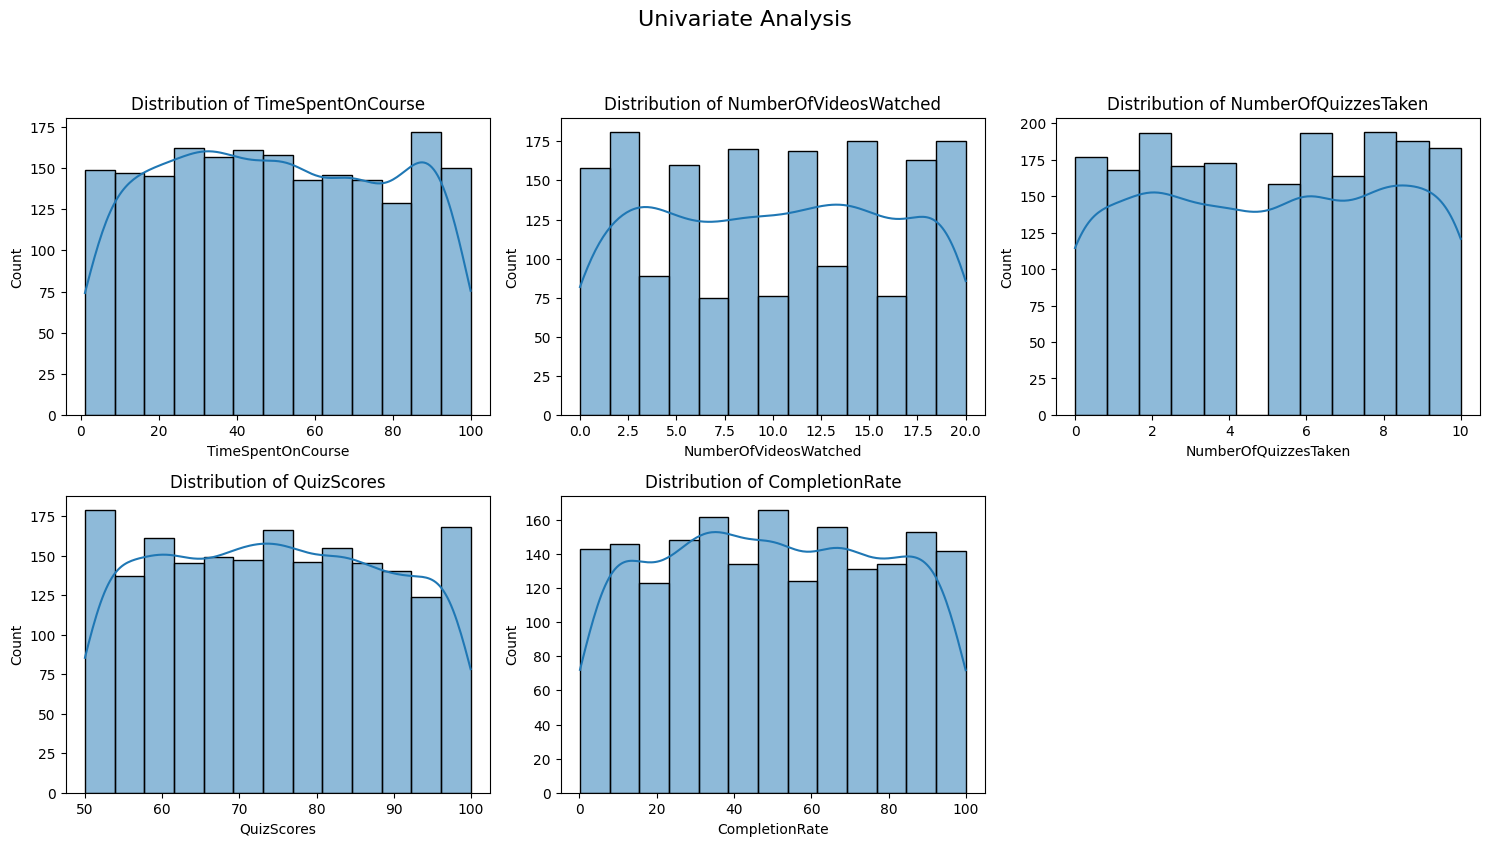

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Univariate Analysis - Histograms and Boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("Univariate Analysis", fontsize=16)

# List of numerical columns for analysis
numerical_cols = ['TimeSpentOnCourse', 'NumberOfVideosWatched', 'NumberOfQuizzesTaken',
                  'QuizScores', 'CompletionRate']

# Plotting distributions
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i // 3, i % 3])
    axes[i // 3, i % 3].set_title(f'Distribution of {col}')
    axes[i // 3, i % 3].set_xlabel(col)

# Removing extra subplots
for j in range(len(numerical_cols), 9):
    fig.delaxes(axes[j // 3, j % 3])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


* **Bi/Multi-Variate Analysis**

    - Descriptive Stats Measures used to study data between two or more columns

    **Bi/Multi-Variate Combo**|**Stats Measures**
    ----|-----------
    **Numeric-Numeric**|**Correlation (-1 to +1)**
    **Numeric-Categorical**|**Aggregation Functions (count, min, max, avg, sum)**
    **Categorical-Categorical**|**FDT**

    

In [ ]:
'''for col in df.columns:
    if col != 'CourseCategory':
        print(df.groupby('CourseCategory')[col].mean())
        print()'''

"for col in df.columns:\n    if col != 'CourseCategory':\n        print(df.groupby('CourseCategory')[col].mean())\n        print()"

Categorical to numarical

In [ ]:
import plotly.express as px

for col in ['UserID', 'TimeSpentOnCourse',
       'NumberOfVideosWatched', 'NumberOfQuizzesTaken', 'QuizScores',
       'CompletionRate', 'DeviceType', 'CourseCompletion']:
    fig = px.box(df, x= 'CourseCategory', y=col, title=f'Distribution of {col} by Cource Type', color= 'CourseCategory')
    fig.update_layout(xaxis_title="Crop Type", yaxis_title=col)
    fig.show()

In [ ]:
for col in ['UserID', 'TimeSpentOnCourse', 'NumberOfVideosWatched', 'NumberOfQuizzesTaken', 'QuizScores',
            'CompletionRate', 'DeviceType', 'CourseCompletion']:
    fig = px.pie(df, values=col, names='CourseCategory', title=f'Distribution of {col} by Course Category')
    fig.show()

Multi-Variate

Heat Map

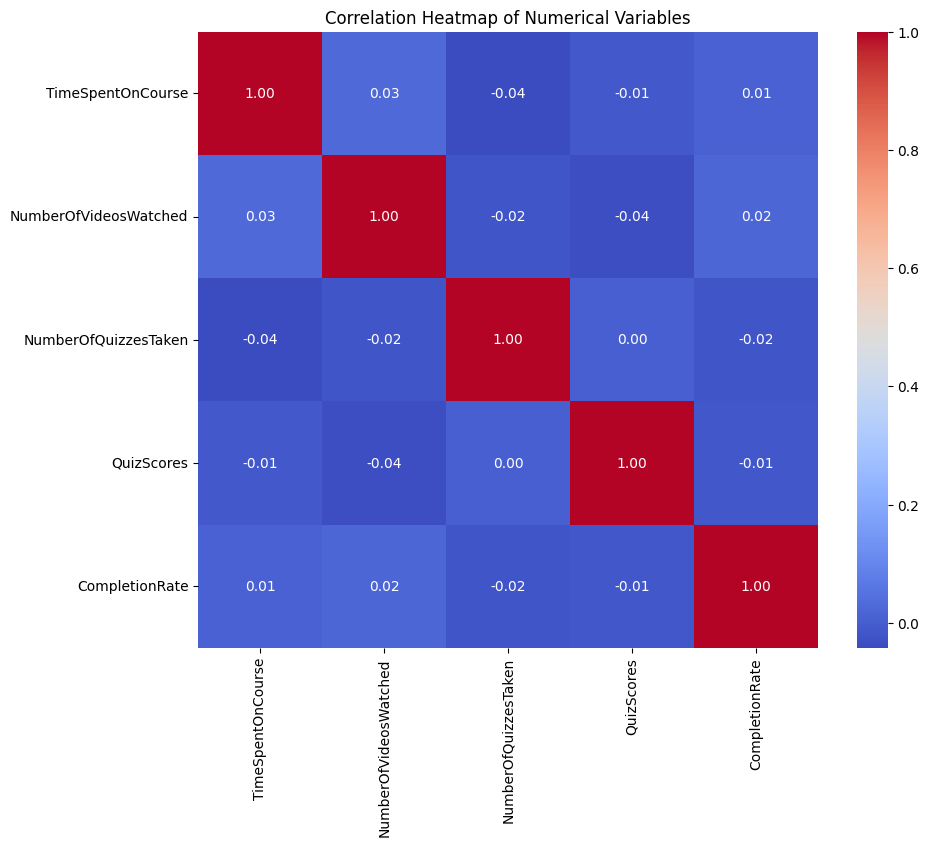

In [ ]:
# Correlation matrix heatmap
correlation_matrix = df[['TimeSpentOnCourse', 'NumberOfVideosWatched', 'NumberOfQuizzesTaken', 'QuizScores', 'CompletionRate']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()


missing values or null values

### 3. Handling Missing Values & Outliers<a id='naout'>
    

    
** NaN (missing data in columns)**

In [ ]:
df.head(5)

,UserID,CourseCategory,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion
0,5618,health,29.98,17.00,3,50.37,20.86,1,0
1,4326,arts,27.80,1.00,5,62.62,65.63,1,0
2,5849,arts,86.82,14.00,2,78.46,63.81,1,1
3,4992,science,35.04,17.00,10,59.20,95.43,0,1
4,3866,programming,92.49,16.00,0,98.43,18.10,0,0


In [ ]:
# Check for missing/null values in the entire dataset
print(df.isnull().sum())

UserID                     0
CourseCategory             0
TimeSpentOnCourse          0
NumberOfVideosWatched    200
NumberOfQuizzesTaken       0
QuizScores                 0
CompletionRate           100
DeviceType                 0
CourseCompletion           0
dtype: int64


**'NumberOfVideosWatched'** This column has null values of 10% so we are going to handle it by equavating it to mean()

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Handle null values for 'Parental_Education' (Categorical)
NumberOfVideosWatched = df['NumberOfVideosWatched'].mean()  # Get the most frequent value
df['NumberOfVideosWatched'].fillna(NumberOfVideosWatched, inplace=True)

In [ ]:
# Check for missing/null values in the entire dataset
print(df.isnull().sum())

UserID                     0
CourseCategory             0
TimeSpentOnCourse          0
NumberOfVideosWatched      0
NumberOfQuizzesTaken       0
QuizScores                 0
CompletionRate           100
DeviceType                 0
CourseCompletion           0
dtype: int64


We are going to cheack the column **'CompletionRate'** we mean, median, mode.

In [ ]:
def missing_data(df,var,mean,median,mode):
  df[var+'_mean']=df[var].fillna(mean)
  df[var+'_median']=df[var].fillna(median)
  df[var+'_mode']=df[var].fillna(mode[0])

In [ ]:
CompletionRate_mean = df['CompletionRate'].mean()
CompletionRate_median = df['CompletionRate'].median()
CompletionRate_mode = df['CompletionRate'].mode()

In [ ]:
missing_data(df,'CompletionRate',CompletionRate_mean,CompletionRate_median,CompletionRate_mode)

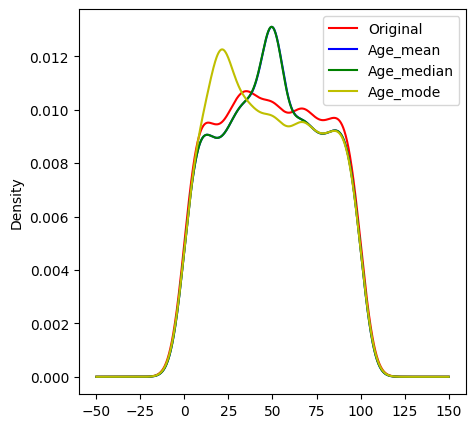

In [ ]:
plt.figure(figsize =(5,5))
df['CompletionRate'].plot(kind='kde',color='r',label='Original')
df['CompletionRate_mean'].plot(kind='kde',color='b',label='Age_mean')
df['CompletionRate_median'].plot(kind='kde',color='g',label='Age_median')
df['CompletionRate_mode'].plot(kind='kde',color='y',label='Age_mode')

plt.legend(loc =0)
plt.show()

Median has more density so we took median and handled the data

In [ ]:
# Handle null values for 'Test_Scores' (Numerical)
CompletionRate_median = df['CompletionRate'].median()
df['CompletionRate'].fillna( CompletionRate_median,inplace=True)

In [ ]:
df=df.drop(['CompletionRate_mean','CompletionRate_mode','CompletionRate'],axis=1)


Final check of Nullvalues

In [ ]:
# Final check of null values
print(df.isnull().sum())

UserID                   0
CourseCategory           0
TimeSpentOnCourse        0
NumberOfVideosWatched    0
NumberOfQuizzesTaken     0
QuizScores               0
DeviceType               0
CourseCompletion         0
CompletionRate_median    0
dtype: int64


 **Future Engenering**

Lable Encoding :It convert the catogorical column into numarical column to do the Predective Modelling

In [ ]:
#Converting categorical data into numarical data by using map function
df['CourseCategory'] = df['CourseCategory'].astype(str).str.strip().str.title()
df['CourseCategory'] = df['CourseCategory'].map({'Health': 1, 'Arts': 2, 'Science': 3, 'Programming': 4, 'Business': 5})

In [ ]:
df.head()

,UserID,CourseCategory,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,DeviceType,CourseCompletion,CompletionRate_median
0,5618,1,29.98,17.00,3,50.37,1,0,20.86
1,4326,2,27.80,1.00,5,62.62,1,0,65.63
2,5849,2,86.82,14.00,2,78.46,1,1,63.81
3,4992,3,35.04,17.00,10,59.20,0,1,95.43
4,3866,4,92.49,16.00,0,98.43,0,0,18.10


Outlayers Handeling

In [ ]:
# Identifying outliers by using IQR
for d in df.columns:
  Q1 = df[d].quantile(0.25)
  Q3 = df[d].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[d] < lower_bound) | (df[d] > upper_bound)][[d]]
  if not outliers.empty:
    print(d)



visualization of outliers before handling null values


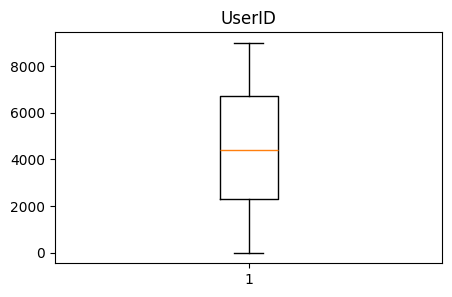

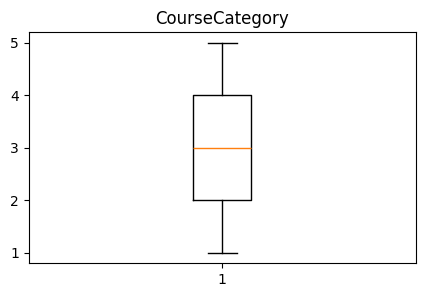

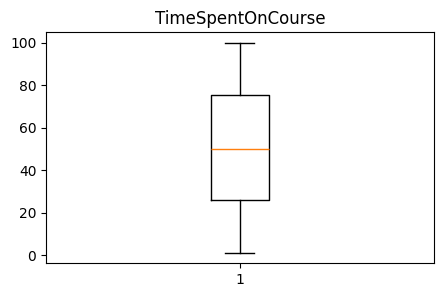

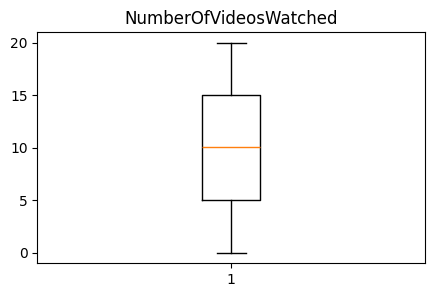

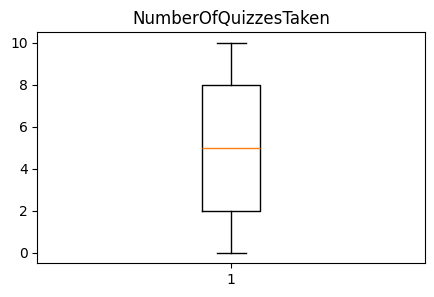

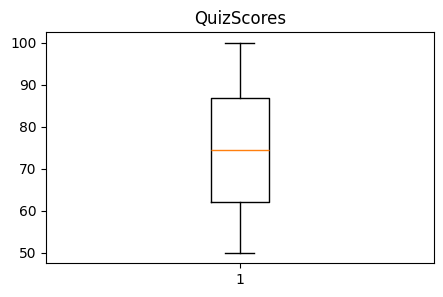

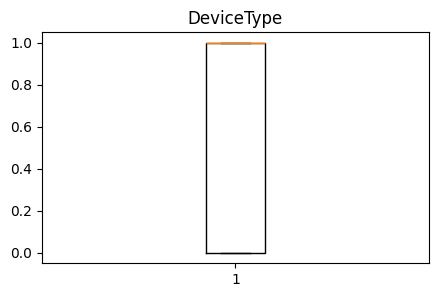

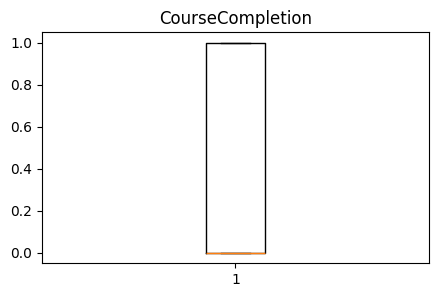

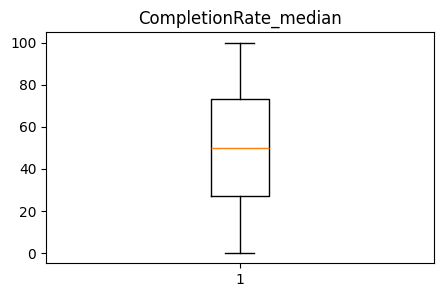

In [ ]:
# visualization of outliers
print('visualization of outliers before handling null values')
for d in df.columns:
  plt.figure(figsize=(5,3))
  plt.boxplot(df[d])
  plt.title(d)
  plt.show()

***Predictive Modelling***


Scice we have Clasification data we took these 7 algorithms to do the **modelling**

**Modeling Procedure**:

* Model Define
* Model Training
* Checking Model Param
* Evaluation - Metrics, Cross validation
* Feature importance
* Visualizations
* Bias-Variance
* Real time prediction

Droping the useless columns **'UserId'**

In [ ]:
#droping useless columns for the modelling
df=df.drop(['UserID'],axis=1)

In [ ]:
X=df.drop(['CourseCompletion'],axis=1)
Y=df['CourseCompletion']

Spliting X and Y

In [ ]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y, random_state=123, test_size=0.2)

In [ ]:
Xtrain.shape

(1569, 7)

In [ ]:
Xtest.shape

(393, 7)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtrain

array([[-1.46399481,  1.34876168, -0.00557415, ..., -1.45641938,
         0.98922314, -0.3032127 ],
       [-1.46399481, -0.39557997,  1.38832423, ..., -0.48628761,
        -1.01089427,  1.52229285],
       [ 1.37707861, -1.07011922, -0.7120597 , ...,  1.08973215,
        -1.01089427,  0.06038853],
       ...,
       [ 0.66681025, -0.41012747, -0.88709169, ..., -1.65849574,
         0.98922314, -1.11673905],
       [ 0.66681025, -1.1169388 , -0.5370277 , ...,  1.09659468,
         0.98922314,  0.54121156],
       [ 1.37707861, -0.78171689,  1.56335622, ..., -0.7370496 ,
        -1.01089427,  0.84165779]])

In [ ]:
Xtest = scaler.transform(Xtest)
Xtest

array([[-1.46399481, -0.53025961,  0.68819625, ..., -0.86444753,
         0.98922314,  1.10925827],
       [ 0.66681025, -0.86410779, -1.58721967, ..., -0.70116488,
         0.98922314, -0.46506603],
       [ 0.66681025,  1.4350964 ,  1.38832423, ..., -0.25725254,
         0.98922314, -0.14573709],
       ...,
       [-1.46399481,  1.01354849,  0.33813226, ..., -0.30430169,
        -1.01089427,  0.93739093],
       [-1.46399481,  1.55770423,  1.03826024, ..., -1.20589201,
         0.98922314, -0.53818623],
       [ 0.66681025,  1.21939525, -1.76225166, ...,  0.66893778,
         0.98922314, -0.74543025]])

In [ ]:
# importing libraries
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost
from xgboost import XGBClassifier


Logistic Regression(LR)

In [ ]:
lr = LogisticRegression(penalty='l2',C=1.0,solver='lbfgs',class_weight='balanced',random_state=42)
lr.fit(Xtrain,Ytrain)


LogisticRegression(class_weight='balanced', random_state=42)

KNeighborsClassifer(KNN)

In [ ]:
kn = KNeighborsClassifier(n_neighbors=5, p=2)
kn.fit(Xtrain,Ytrain)

KNeighborsClassifier()

Support Vector Machine(SVM)

In [ ]:
sv = SVC(kernel = 'rbf', gamma=5)
sv.fit(Xtrain,Ytrain)

SVC(gamma=5)

Naive Bayes(NB)

In [ ]:
nv = GaussianNB(var_smoothing=1e-9)
nv.fit(Xtrain,Ytrain)

GaussianNB()

Decision Tree(DT)

In [ ]:
dt = DecisionTreeClassifier(criterion='entropy',max_depth=10,random_state=42)
dt.fit(Xtrain,Ytrain)

DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)

Random Forest (RF)

In [ ]:
rf = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)
rf.fit(Xtrain,Ytrain)

RandomForestClassifier(max_depth=10, random_state=42)

XGBoost(XGB)

In [ ]:
xg = XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=6,gamma=0.1,random_state=42)
xg.fit(Xtrain,Ytrain)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

Tree Visualization

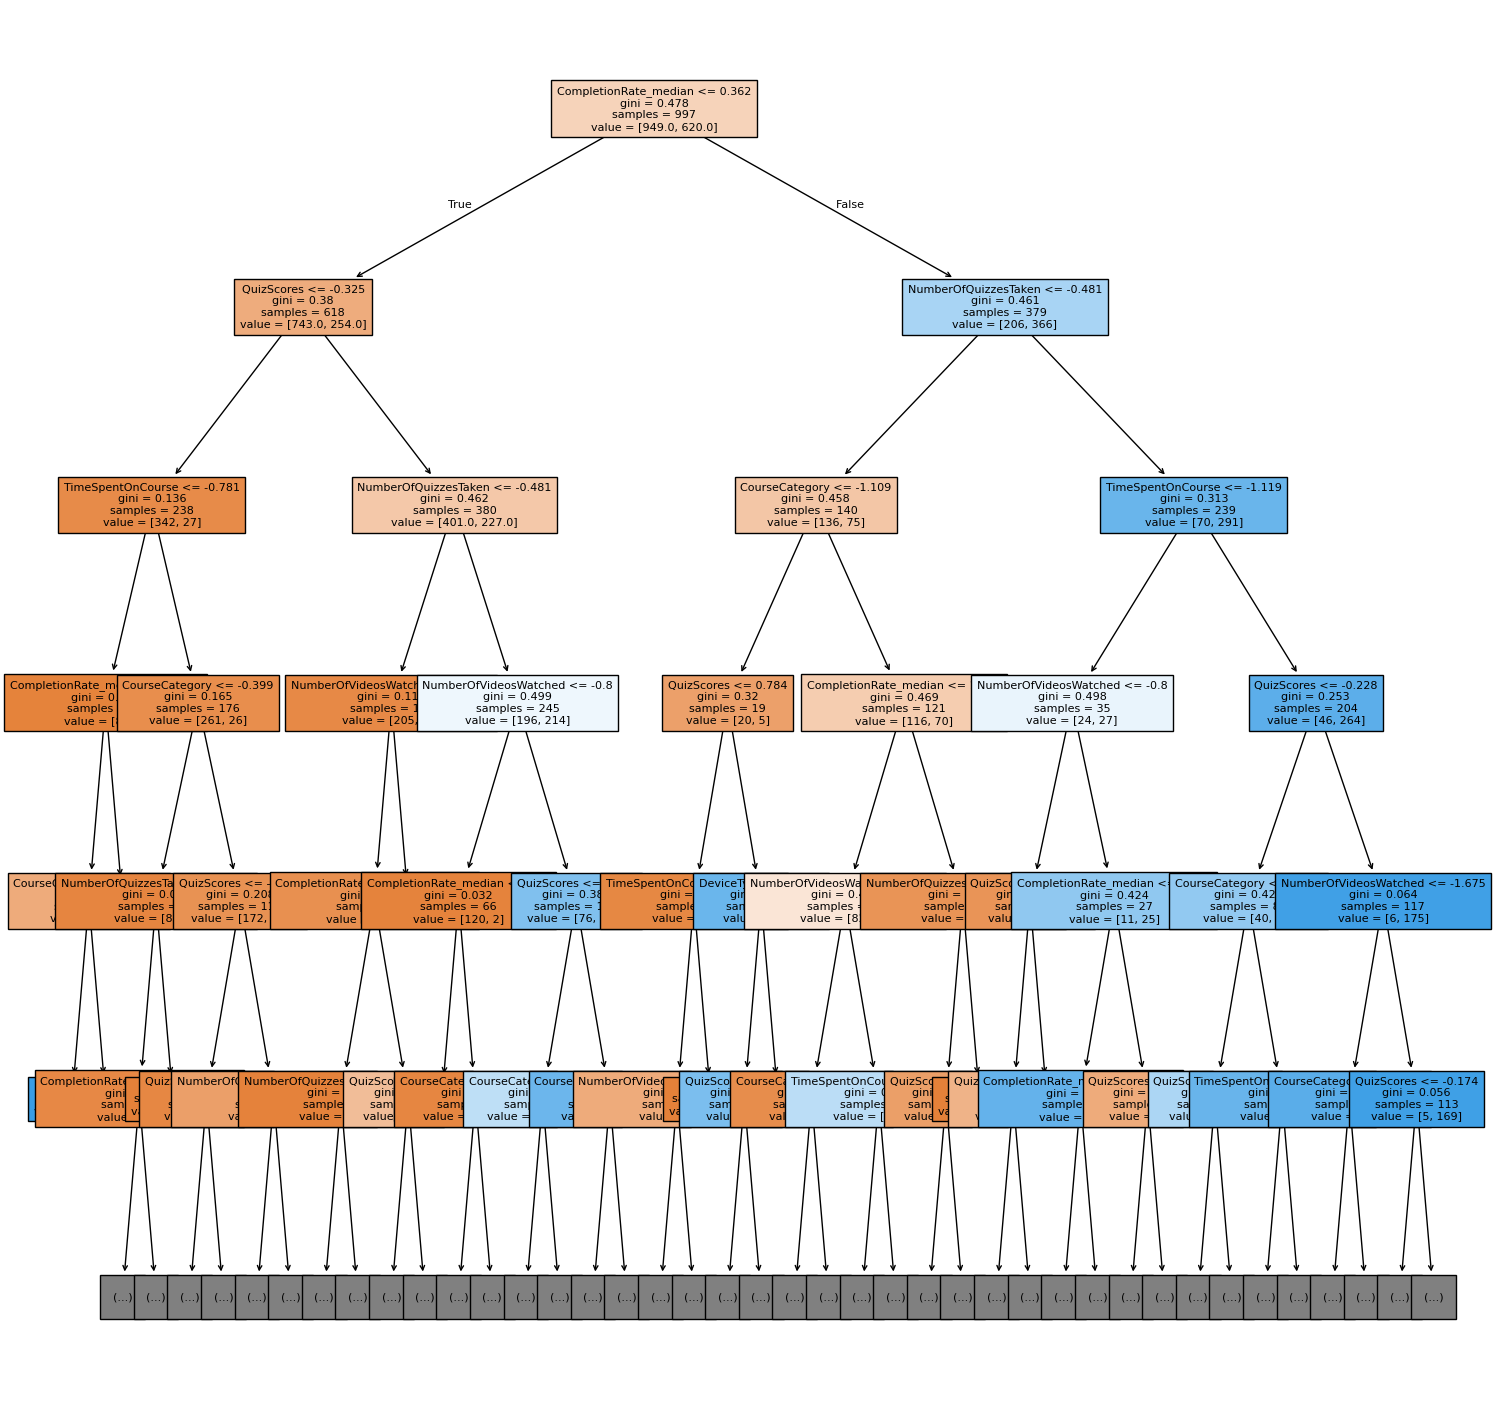

In [ ]:
# Tree Visualization
import pandas as pd
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,18))
# Get the original feature names from the 'X' DataFrame (before scaling)
feature_names = X.columns
plot_tree(rf.estimators_[0],filled=True,fontsize=8,feature_names=feature_names,max_depth=5)
plt.show()

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
names=['Logistic Regression','Knearest Neighbors','Support Vector Machine','Naive Bayes','Decision Trees','Random Forest','Xgboost']
model= [lr,kn,sv,nv,dt,rf,xg]

In [ ]:
!pip install simple-colors
from simple_colors import *

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,auc,roc_curve
from sklearn.model_selection import cross_val_score

In [ ]:
trainscore = []
testscore = []
fit = []
crossvalscore = []

In [ ]:


for i in range(len(model)):

    if model[i] == sv:

        ytrain_sv = np.where(Ytrain == 'yes',1,0)
        ytest_sv = np.where(Ytest == 'yes',1,0)

        ytrain_pred = model[i].predict(Xtrain)
        ytest_pred = model[i].predict(Xtest)

        # Accuracy Score
        acc_score_tr = round(accuracy_score(ytrain_sv, ytrain_pred),2)
        acc_score_te = round(accuracy_score(ytest_sv, ytest_pred),2)

        trainscore.append(acc_score_tr)
        testscore.append(acc_score_te)

        # Bias-Variance Trade off
        trscore = acc_score_tr
        tescore = acc_score_te

        if trscore<0.50 and tescore<0.50:
            if abs(trscore)==0 and abs(tescore)==0:
                fit.append("Nofit")
            else:
                fit.append("Underfit")

        else:
            if abs(trscore-tescore)<0.10:
                fit.append("Goodfit")
            elif abs(trscore-tescore)>=0.10:
                fit.append("Overfit")
            else:
                fit.append("Fit")



        # Cross-val score
        scores = cross_val_score(model[i], X,Y, cv=3)
        crossvalscore.append(round(scores.mean(),2))

    else:

        ytrain_pred = model[i].predict(Xtrain)
        ytest_pred = model[i].predict(Xtest)

        # Accuracy Score
        acc_score_tr = round(accuracy_score(Ytrain, ytrain_pred),2)
        acc_score_te = round(accuracy_score(Ytest, ytest_pred),2)

        trainscore.append(acc_score_tr)
        testscore.append(acc_score_te)

        # Bias-Variance Trade Off
        trscore = acc_score_tr
        tescore = acc_score_te


        if trscore<0.50 and tescore<0.50:
            if abs(trscore)==0 and abs(tescore)==0:
                fit.append("Nofit")
            else:
                fit.append("Underfit")

        else:
            if abs(trscore-tescore)<0.10:
                fit.append("Goodfit")
            elif abs(trscore-tescore)>=0.10:
                fit.append("Overfit")
            else:
                fit.append("Fit")

        # Cross-val score
        scores = cross_val_score(model[i], X, Y, cv=3)
        crossvalscore.append(round(scores.mean(),2))



In [ ]:
print(len(names))
print(len(trainscore))
print(len(testscore))
print(len(fit))
print(len(crossvalscore))

7
7
7
7
7


LogisticRegression(class_weight='balanced', random_state=42):
classification_report of LogisticRegression(class_weight='balanced', random_state=42) : 
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       239
           1       0.94      0.90      0.92       154

    accuracy                           0.94       393
   macro avg       0.94      0.93      0.93       393
weighted avg       0.94      0.94      0.94       393

confusion_matrix of LogisticRegression(class_weight='balanced', random_state=42) : 


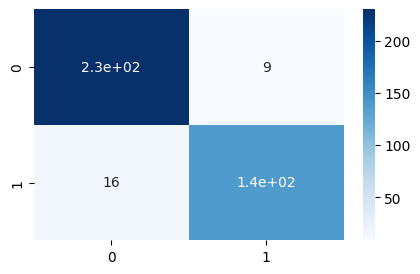

________________________________________________________________
KNeighborsClassifier():
classification_report of KNeighborsClassifier() : 
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       239
           1       0.94      0.90      0.92       154

    accuracy                           0.94       393
   macro avg       0.94      0.93      0.93       393
weighted avg       0.94      0.94      0.94       393

confusion_matrix of KNeighborsClassifier() : 


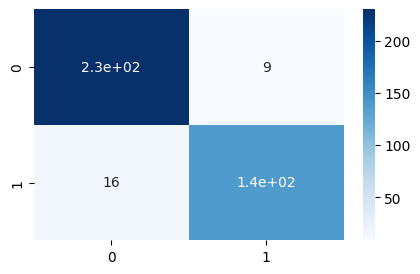

________________________________________________________________
SVC(gamma=5):
classification_report of SVC(gamma=5) : 
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       239
           1       0.94      0.90      0.92       154

    accuracy                           0.94       393
   macro avg       0.94      0.93      0.93       393
weighted avg       0.94      0.94      0.94       393

confusion_matrix of SVC(gamma=5) : 


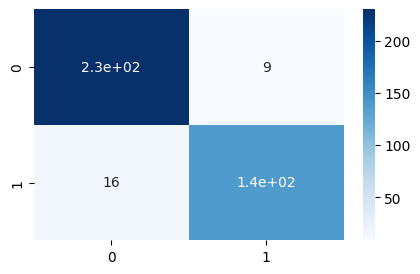

________________________________________________________________
GaussianNB():
classification_report of GaussianNB() : 
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       239
           1       0.94      0.90      0.92       154

    accuracy                           0.94       393
   macro avg       0.94      0.93      0.93       393
weighted avg       0.94      0.94      0.94       393

confusion_matrix of GaussianNB() : 


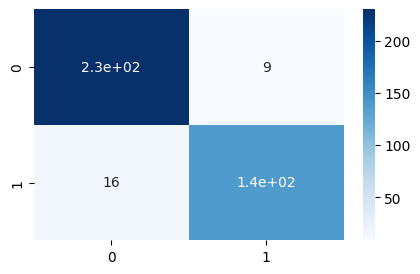

________________________________________________________________
DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42):
classification_report of DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42) : 
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       239
           1       0.94      0.90      0.92       154

    accuracy                           0.94       393
   macro avg       0.94      0.93      0.93       393
weighted avg       0.94      0.94      0.94       393

confusion_matrix of DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42) : 


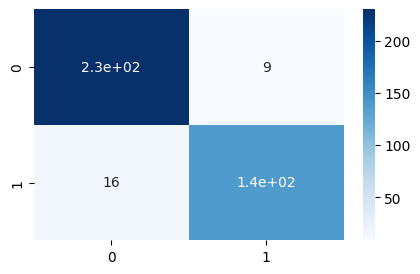

________________________________________________________________
RandomForestClassifier(max_depth=10, random_state=42):
classification_report of RandomForestClassifier(max_depth=10, random_state=42) : 
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       239
           1       0.94      0.90      0.92       154

    accuracy                           0.94       393
   macro avg       0.94      0.93      0.93       393
weighted avg       0.94      0.94      0.94       393

confusion_matrix of RandomForestClassifier(max_depth=10, random_state=42) : 


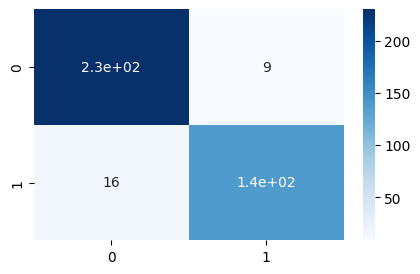

________________________________________________________________
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...):
classification_report of XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, 

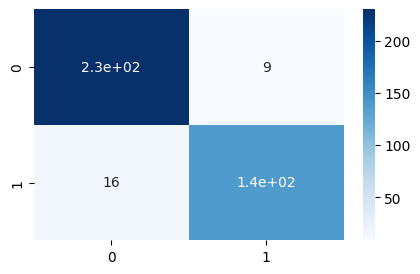

________________________________________________________________


In [ ]:
import seaborn as sns
for i in model:
  print(f'{i}:')
  print(f'classification_report of {i} : ')
  print(f'{classification_report(Ytest,ytest_pred)}')
  plt.figure(figsize=(5,3))
  print(f'confusion_matrix of {i} : ')
  sns.heatmap(confusion_matrix(Ytest,ytest_pred),annot=True,cmap='Blues')
  plt.show()
  print('________________________________________________________________')


In [ ]:
pd.DataFrame({
    'Model': names,
    'Train Score': trainscore,
    'Test Score': testscore,
    'Fit': fit,
    'Cross Val Score': crossvalscore
})

,Model,Train Score,Test Score,Fit,Cross Val Score
0,Logistic Regression,0.78,0.78,Goodfit,0.77
1,Knearest Neighbors,0.88,0.83,Goodfit,0.76
2,Support Vector Machine,0.61,0.99,Overfit,0.61
3,Naive Bayes,0.81,0.82,Goodfit,0.81
4,Decision Trees,0.98,0.91,Goodfit,0.88
5,Random Forest,0.98,0.94,Goodfit,0.93
6,Xgboost,0.98,0.94,Goodfit,0.92


Cheacking the Y column weather our data has balance or inbalance

In [ ]:
df.CourseCompletion.value_counts()

,count
CourseCompletion,
0,1200
1,762


Since our data is inballence we are taking f1 soce to decide our alogorithm

In [ ]:
from sklearn.metrics import f1_score

f1_score_train=[]
f1_score_test=[]
for i in [lr,kn,sv,nv,dt,rf,xg]:
  i.fit(Xtrain,Ytrain)
  ytrain_pred= i.predict(Xtrain)
  # Use f1_score function instead of the list variable
  f1_score_train.append(f1_score(Ytrain,ytrain_pred))
  ytest_pred= i.predict(Xtest)
  # Use f1_score function instead of the list variable
  f1_score_test.append(f1_score(Ytest,ytest_pred))
print(f1_score_train)
print(f1_score_test)

[0.7278334618350039, 0.8497925311203319, 0.9991769547325103, 0.7188940092165899, 0.9743589743589743, 0.9743589743589743, 0.9752066115702479]
[0.7306501547987616, 0.7622377622377622, 0.03821656050955414, 0.7333333333333333, 0.881578947368421, 0.9163879598662207, 0.9169435215946844]


In [ ]:
Performance=pd.DataFrame(columns=['Model','Train F1 score','Test F1 score'])
Performance['Model']=['Logistic Regression','Knearest Neighbors','Support Vector Machine','Naive Bayes','Decision Trees','Random Forest','Xgboost']
Performance['Train F1 score']=f1_score_train
Performance['Test F1 score']=f1_score_test
Performance['Difference']=Performance['Train F1 score']-Performance['Test F1 score']
Performance

,Model,Train F1 score,Test F1 score,Difference
0,Logistic Regression,0.73,0.73,-0.00
1,Knearest Neighbors,0.85,0.76,0.09
2,Support Vector Machine,1.00,0.04,0.96
3,Naive Bayes,0.72,0.73,-0.01
4,Decision Trees,0.97,0.88,0.09
5,Random Forest,0.97,0.92,0.06
6,Xgboost,0.98,0.92,0.06


**Random Forest** algorithm has high train and test scores we are taking **RF** alogorithm for our Predective Modelling

In [ ]:
inpdata = pd.read_csv("/content/online_course_engagement_data.csv")
inpdata.head(2)

,UserID,CourseCategory,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion
0,5618,Health,29.98,17,3,50.37,20.86,1,0
1,4326,Arts,27.80,1,5,62.62,65.63,1,0


In [ ]:
def Online_Engagement_prediction():

    print("Reference Data for Input:")
    display(inpdata.head())
    print("Random_Forest built on the below X columns:")
    print()
    print(inpdata.columns)
    print("======================= Enter User Input Data ====================")
    print()
    print("Enter CourseCategory :")
    while True:
        try:
            CourseCategory = float(input())
            break  # Exit loop if input is valid
        except ValueError:
            print("Invalid input. Please enter a number for CourseCategory.")
    print()
    print("Enter Time Spent On Course:")
    while True:
        try:
            TimeSpentOnCourse = float(input())
            break
        except ValueError:
            print("Invalid input. Please enter a number for Time Spent On Course.")
    print()
    print("Enter Number Of Videos Watched:")
    while True:
        try:
            NumberOfVideosWatched = float(input())
            break
        except ValueError:
            print("Invalid input. Please enter a number for Number Of Videos Watched.")
    print()
    print("Enter Number Of Quizzes Taken:")
    while True:
        try:
            NumberOfQuizzesTaken = float(input())
            break
        except ValueError:
            print("Invalid input. Please enter a number for Number Of Quizzes Taken.")
    print()
    print("Enter Quiz Scores:")
    while True:
        try:
            QuizScores = float(input())
            break
        except ValueError:
            print("Invalid input. Please enter a number for Quiz Scores.")
    print()
    print("Enter Completion Rate	:")
    while True:
        try:
            CompletionRate = float(input())
            break
        except ValueError:
            print("Invalid input. Please enter a number for Completion Rate.")
    print()
    print("Enter Device Type:")
    while True:
        try:
            DeviceType = float(input())
            break
        except ValueError:
            print("Invalid input. Please enter a number for Device Type.")
            # The fix: Adjust the columns to match the number of data values
    row = pd.DataFrame([[CourseCategory,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType]], columns = inpdata.columns[:-1].drop('UserID'))
    # We drop 'UserID' from the columns because it's not in your input values.

    print("Given User Input Data:")
    display(row)
    print()

    ####### Data Pre-Processing #######

    #row.iloc[:,[1,2,4,5,7]] = sc.fit_transform(row.iloc[:,[1,2,4,5,7]])

    print("********** Prediction ***********")
    print()
    prob0 = round(float(rf.predict_proba(row)[0][0]),2)
    prob1 = round(float(rf.predict_proba(row)[0][1]),2)

    print("Online Engagement prediction: no - {}, yes - {}".format(prob0, prob1))
    print()
    out = rf.predict(row)[0]

    cats = {1:'yes',0:'no'}

    print("Online Engagement prediction:", cats[out])




##Real Time Predection


In [ ]:
Online_Engagement_prediction()


Reference Data for Input:


,UserID,CourseCategory,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion
0,5618,Health,29.98,17,3,50.37,20.86,1,0
1,4326,Arts,27.80,1,5,62.62,65.63,1,0
2,5849,Arts,86.82,14,2,78.46,63.81,1,1
3,4992,Science,35.04,17,10,59.20,95.43,0,1
4,3866,Programming,92.49,16,0,98.43,18.10,0,0


Random_Forest built on the below X columns:

Index(['UserID', 'CourseCategory', 'TimeSpentOnCourse',
       'NumberOfVideosWatched', 'NumberOfQuizzesTaken', 'QuizScores',
       'CompletionRate', 'DeviceType', 'CourseCompletion'],
      dtype='object')
======================= Enter User Input Data ====================

Enter CourseCategory :
Health
Invalid input. Please enter a number for CourseCategory.
2

Enter Time Spent On Course:
29.98

Enter Number Of Videos Watched:
17

Enter Number Of Quizzes Taken:
3

Enter Quiz Scores:
60.37

Enter Completion Rate	:
20.23

Enter Device Type:
1
Given User Input Data:


,CourseCategory,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType
0,2.00,29.98,17.00,3.00,60.37,20.23,1.00



********** Prediction ***********

Online Engagement prediction: no - 0.02, yes - 0.98

Online Engagement prediction: yes


Saving the Model by using **Pickle**

In [ ]:
import pickle
model = open('modelrf.pkl','wb')
pickle.dump(rf,model)
model.close()



In [ ]:
import pandas as pd

df.to_csv("cleaned_dataset.csv", index=False)